In [1]:
import os
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
original_dataset_dir = r"E:\datasets"  # Change this to your actual dataset location
base_dir = r"E:\AI TOOL\preprocessed"  # The new dataset directory

# Define train & validation directories
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")

# Create directories if not exist
for dir_path in [train_dir, val_dir]:
    os.makedirs(dir_path, exist_ok=True)

# Create subdirectories for each class (e.g., NSFW, SFW)
classes = ["NSFW", "SFW"]
for class_name in classes:
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

# Split the dataset (Assuming you have two folders inside "raw" - "NSFW" and "SFW")
for class_name in classes:
    src_dir = os.path.join(original_dataset_dir, class_name)
    files = os.listdir(src_dir)
    
    # Shuffle the files
    import random
    random.shuffle(files)
    
    split = int(0.8 * len(files))  # 80% for training, 20% for validation
    train_files = files[:split]
    val_files = files[split:]
    
    # Copy files to train & val directories
    for file in train_files:
        shutil.copy(os.path.join(src_dir, file), os.path.join(train_dir, class_name, file))
    
    for file in val_files:
        shutil.copy(os.path.join(src_dir, file), os.path.join(val_dir, class_name, file))

print("Dataset Preprocessing Complete! Saved to 'dataset/train' and 'dataset/validation'.")

Dataset Preprocessing Complete! Saved to 'dataset/train' and 'dataset/validation'.


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Use 'softmax' for multi-class
])

# Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\Bhuvana Sankar\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Load Dataset Again
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    r"E:\datasets\train",  # Change this to the correct path
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
     r"E:\datasets\validation",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Train the Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    batch_size=32
)

# Save the Trained Model
model.save("securelens_model.h5")

print("Model Training Complete! Saved as 'securelens_model.h5'.")

Found 2394 images belonging to 2 classes.
Found 1438 images belonging to 2 classes.


C:\Users\Bhuvana Sankar\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.5745 - loss: 2.3575 - val_accuracy: 0.7399 - val_loss: 0.5368
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7109 - loss: 0.5614 - val_accuracy: 0.7594 - val_loss: 0.4898
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7289 - loss: 0.5445 - val_accuracy: 0.7663 - val_loss: 0.4980
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.7584 - loss: 0.5129 - val_accuracy: 0.8178 - val_loss: 0.4187
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.7951 - loss: 0.4504 - val_accuracy: 0.8609 - val_loss: 0.3679
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8236 - loss: 0.4029 - val_accuracy: 0.8790 - val_loss: 0.3285
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.8154 - loss: 0.4079 - val_accuracy: 0.8992 - val_loss: 0.2731
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8265 - loss: 0.3771 - val_accuracy: 0.9159 - v

Model Training Complete! Saved as 'securelens_model.h5'.


In [7]:
loss, accuracy = model.evaluate(val_data)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - accuracy: 0.8825 - loss: 0.2341
Validation Accuracy: 87.97%
Validation Loss: 0.2509


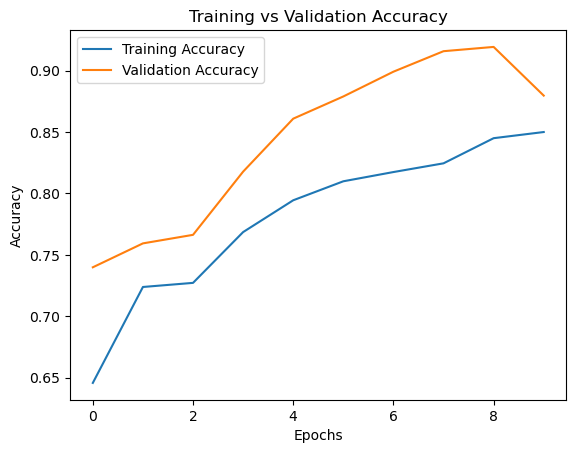

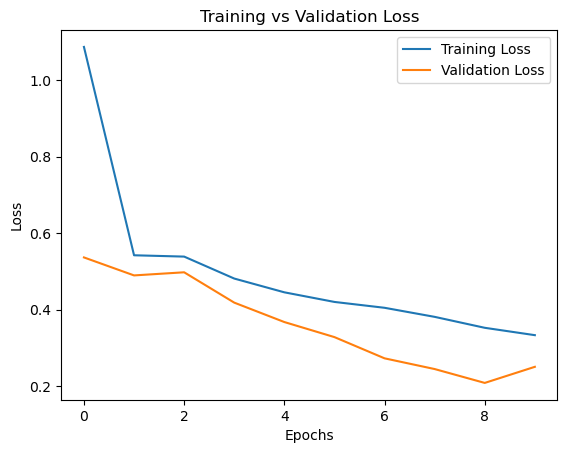

In [9]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = r"E:\datasets\SFW\aug_image_303_0_6622.jpg"  # Replace with actual test image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize

prediction = model.predict(img_array)
print("Predicted Class:", "Class 1" if prediction > 0.5 else "Class 0")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
Predicted Class: Class 1


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = val_data.classes
y_pred = np.round(model.predict(val_data))

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 291ms/step
Confusion Matrix:
 [[434 284]
 [433 287]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.60      0.55       718
           1       0.50      0.40      0.44       720

    accuracy                           0.50      1438
   macro avg       0.50      0.50      0.50      1438
weighted avg       0.50      0.50      0.50      1438



In [15]:
import numpy as np
print("Class distribution in training set:", np.bincount(train_data.classes))
print("Class distribution in validation set:", np.bincount(val_data.classes))

Class distribution in training set: [1198 1196]
Class distribution in validation set: [718 720]


In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight("balanced", classes=np.unique(train_data.classes), y=train_data.classes)
class_weights = dict(enumerate(class_weights))

model.fit(train_data, validation_data=val_data, epochs=10, batch_size=32, class_weight=class_weights)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8775 - loss: 0.2919 - val_accuracy: 0.9019 - val_loss: 0.2556
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8665 - loss: 0.2978 - val_accuracy: 0.9291 - val_loss: 0.1748
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8873 - loss: 0.2500 - val_accuracy: 0.9332 - val_loss: 0.1689
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8892 - loss: 0.2541 - val_accuracy: 0.9478 - val_loss: 0.1431
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9022 - loss: 0.2296 - val_accuracy: 0.9409 - val_loss: 0.1573
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8927 - loss: 0.2361 - val_accuracy: 0.9325 - val_loss: 0.1702
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9079 - loss: 0.2313 - val_accuracy: 0.9694 - val_loss: 0.0948
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.9186 - loss: 0.1920 - val_accuracy: 0.8839 - v

In [19]:
loss, accuracy = model.evaluate(val_data)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 262ms/step - accuracy: 0.9623 - loss: 0.0994
Validation Accuracy: 95.90%
Validation Loss: 0.1015


In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get true labels from validation generator
y_true = val_data.classes  # True class labels

# Get predictions
y_pred = model.predict(val_data)
y_pred_classes = (y_pred > 0.5).astype("int32")  # Convert probabilities to binary class labels

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))


45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 271ms/step
Confusion Matrix:
[[373 345]
 [388 332]]
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.52      0.50       718
           1       0.49      0.46      0.48       720

    accuracy                           0.49      1438
   macro avg       0.49      0.49      0.49      1438
weighted avg       0.49      0.49      0.49      1438



In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1.0/255)  # No augmentation for validation

In [27]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the pretrained model

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),  # Helps prevent overfitting
    tf.keras.layers.Dense(1, activation="sigmoid")  # Binary classification
])

In [29]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)  # Lower LR for stable learning
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
print(dir())

['Adam', 'Conv2D', 'Dense', 'Flatten', 'ImageDataGenerator', 'In', 'MaxPooling2D', 'MobileNetV2', 'Out', 'Sequential', '_', '_10', '_12', '_14', '_16', '_17', '_18', '_2', '_20', '_22', '_24', '_26', '_28', '_30', '_32', '_4', '_6', '_8', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__pandas', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'accuracy', 'base_dir', 'base_model', 'class_name', 'class_weights', 'classes', 'classification_report', 'compute_class_weight', 'confusion_matrix', 'dataframe_columns', 'dataframe_hash', 'dir_path', 'dtypes_str', 'exit', 'file', 'files', 'get_dataframes', 'get_ipython', 'getpass', 'hashlib', 'history', 'image', 'img', 'img_arr

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_dataset = train_datagen.flow_from_directory(
    r"E:\datasets\train",  # Update this with the correct dataset path
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_dataset = train_datagen.flow_from_directory(
    r"E:\datasets\validation",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)


Found 1916 images belonging to 2 classes.
Found 287 images belonging to 2 classes.


In [37]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

C:\Users\Bhuvana Sankar\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 53s 671ms/step - accuracy: 0.8236 - loss: 0.3881 - val_accuracy: 0.8711 - val_loss: 0.2538
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 569ms/step - accuracy: 0.9844 - loss: 0.0735 - val_accuracy: 0.8815 - val_loss: 0.2197
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 608ms/step - accuracy: 0.9907 - loss: 0.0429 - val_accuracy: 0.9024 - val_loss: 0.1985
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 605ms/step - accuracy: 0.9940 - loss: 0.0273 - val_accuracy: 0.9094 - val_loss: 0.1870
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 595ms/step - accuracy: 0.9967 - loss: 0.0215 - val_accuracy: 0.9199 - val_loss: 0.1757
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 37s 624ms/step - accuracy: 0.9975 - loss: 0.0157 - val_accuracy: 0.9199 - val_loss: 0.1754
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 671ms/step - accuracy: 0.9959 - loss: 0.0140 - val_accuracy: 0.9164 - val_loss: 0.1658
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 38s 630ms/step - accuracy: 0.9965 - loss: 0.0142 - val_accu

In [39]:
loss, accuracy = model.evaluate(val_data)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 554ms/step - accuracy: 0.9793 - loss: 0.0356
Validation Accuracy: 98.33%
Validation Loss: 0.0364


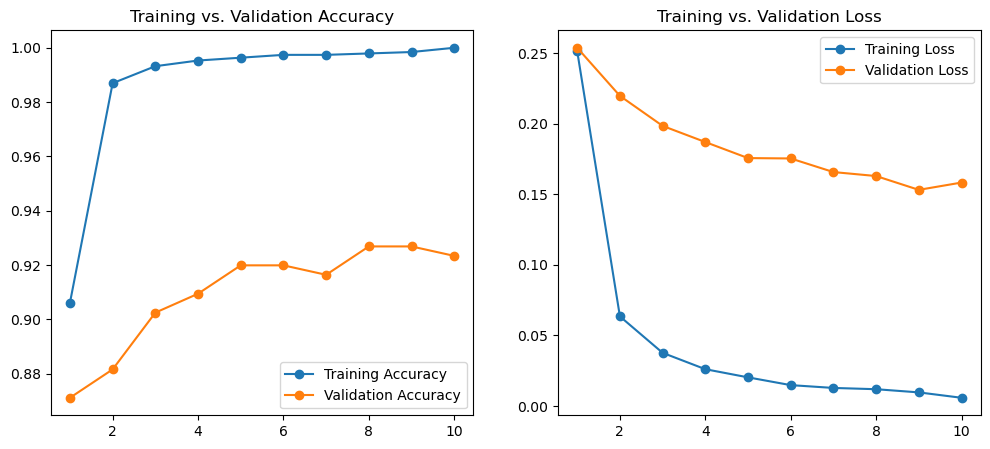

In [41]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, 11)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend()
plt.title('Training vs. Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend()
plt.title('Training vs. Validation Loss')

plt.show()

In [43]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [45]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)  # Reduce learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 581ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67       718
           1       0.00      0.00      0.00       720

    accuracy                           0.50      1438
   macro avg       0.25      0.50      0.33      1438
weighted avg       0.25      0.50      0.33      1438



C:\Users\Bhuvana Sankar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Bhuvana Sankar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Bhuvana Sankar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


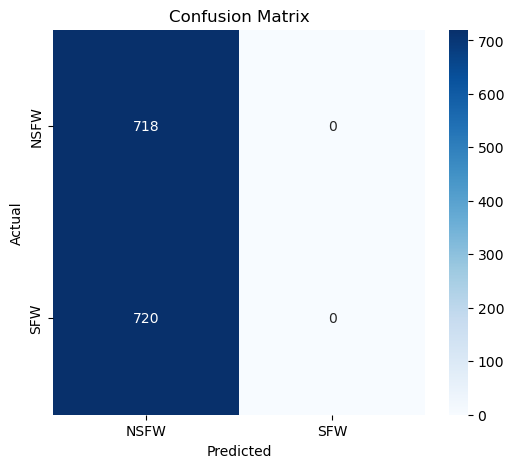

In [47]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predicted labels
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = val_data.classes  # True labels

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=val_data.class_indices.keys(), yticklabels=val_data.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


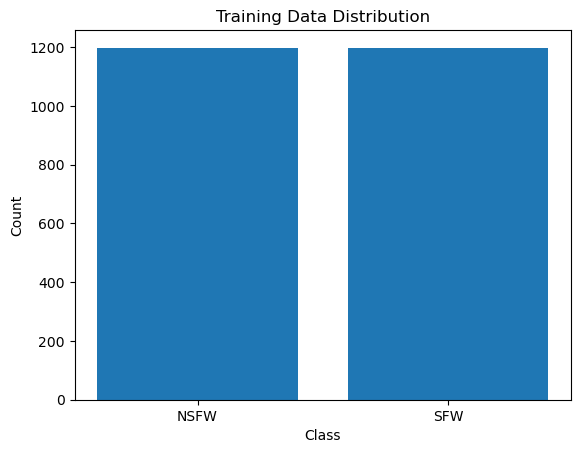

In [48]:
import numpy as np
import matplotlib.pyplot as plt

labels = train_data.classes
unique, counts = np.unique(labels, return_counts=True)

plt.bar(unique, counts)
plt.xticks(unique, list(train_data.class_indices.keys()))
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Training Data Distribution")
plt.show()

In [51]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

model.fit(train_data, validation_data=val_data, epochs=10, class_weight=class_weights_dict)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9782 - loss: 0.0604 - val_accuracy: 0.9868 - val_loss: 0.0330
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9794 - loss: 0.0482 - val_accuracy: 0.9875 - val_loss: 0.0251
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9838 - loss: 0.0515 - val_accuracy: 0.9924 - val_loss: 0.0215
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9875 - loss: 0.0362 - val_accuracy: 0.9903 - val_loss: 0.0226
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9803 - loss: 0.0499 - val_accuracy: 0.9910 - val_loss: 0.0218
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9809 - loss: 0.0411 - val_accuracy: 0.9937 - val_loss: 0.0172
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.9867 - loss: 0.0360 - val_accuracy: 0.9924 - val_loss: 0.0171
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9873 - loss: 0.0298 - val_accuracy: 0.9917 - val_loss

In [ ]:
loss, accuracy = model.evaluate(val_data)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

print(classification_report(y_true, y_pred_classes, target_names=list(val_data.class_indices.keys()))) 

In [ ]:
import tensorflow as tf

# Save the model
model.save("AI_model.h5")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load and preprocess the image
def preprocess_image(img_path, img_size=(224, 224)):  # Adjust size to match your model input
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0  # Normalize (0-1)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Example: Predict a test image
img_path = r"C:\Users\Bhuvana Sankar\Downloads\WhatsApp Image 2025-03-07 at 17.18.56_3d77b914.jpg"  # Change to your image path
img_array = preprocess_image(img_path)

# Display the image
plt.imshow(image.load_img(img_path))
plt.axis("off")
plt.show()

In [ ]:
# Get prediction from model
pred = model.predict(img_array)[0][0]  # Assuming binary classification with sigmoid activation

# Convert prediction to class label
threshold = 0.5  # Default threshold for binary classification
label = "SFW" if pred >= threshold else "NSFW"
confidence = round(pred * 100, 2) if pred >= threshold else round((1 - pred) * 100, 2)

# Print result with strict conditions
if label == "NSFW":
    if confidence > 80:
        print(f"🚫 Prediction: NSFW ({confidence}% confidence)\n❌ This image CANNOT be posted.")
    else:
        print(f"⚠️ Prediction: NSFW ({confidence}% confidence)\n⚠️ Double-check before posting.")
else:
    print(f"✅ Prediction: SFW ({confidence}% confidence)\n✔️ This image is ELIGIBLE to post.")